<a href="https://colab.research.google.com/github/oumaimabelgaied/GNN_fraud_detection/blob/main/GCN_Elliptic_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Convolutional Network for Bitcoin Fraud Detection
## Replication & Extension of Alarab et al. (2020)

---

### Abstract

This notebook implements and extends the Graph Convolutional Network (GCN) model proposed in **Alarab et al. (2020)** *"Competence of Graph Convolutional Networks for Anti-Money Laundering in Bitcoin Blockchain"* for node classification on the **Elliptic dataset**.

**Problem:** Detect illicit (money-laundering) transactions in the Bitcoin transaction graph, a highly imbalanced binary node classification task (~10% illicit, ~90% licit among labelled nodes).

**Method:** A hybrid GCN architecture combining:
- A 2-layer GCN branch with random-walk normalisation (D⁻¹A) operating on the transaction graph
- A parallel linear branch operating on raw node features in Euclidean space
- Concatenation of both branches followed by two fully-connected layers

**Contribution / Extension:** We evaluate the model under two experimental protocols:
- **Experiment A — 80/20 stratified split:** 80% of labelled nodes for training, 20% for validation (ignoring temporal structure)
- **Experiment B — Temporal split (paper protocol):** Timesteps 1–34 for training, timesteps 35–49 for testing, respecting the chronological ordering of the data

Results are compared side-by-side on F1, Precision, Recall, AUROC and AUPRC metrics.

---
**Dataset:** Elliptic (https://www.kaggle.com/ellipticco/elliptic-data-set)  
**Framework:** PyTorch Geometric (PyG)  
**Reference:** Alarab et al., ACM ICBC 2020

## 1. Environment Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

folder_path1 = "/content/drive/MyDrive/PFART4"
print(f"✓ Drive monté - Dossier: {folder_path1}")

Mounted at /content/drive
✓ Drive monté - Dossier: /content/drive/MyDrive/PFART4


In [ ]:
!pip install torch-geometric -q

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA disponible: True


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops, degree
from torch_geometric.data import Data

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch : {torch.__version__}')

# ── Global configuration (single source of truth) ────────────────────────────
# Hyperparameters — Section 4 of Alarab et al. (2020)
LEARNING_RATE    = 0.001
WEIGHT_DECAY     = 5e-4
NUM_EPOCHS       = 300
PATIENCE         = 100     # early stopping (extension over paper)
DROPOUT_P        = 0.5
CONV1_DIM        = 50
CONV2_DIM        = 10
LINEAR1_DIM      = 81
LINEAR2_DIM      = 100
NUM_CLASSES      = 2

# Temporal split definition — paper Section 4
TRAIN_TS         = list(range(1, 30))   # timesteps 1..34  → train
VAL_TS   = list(range(30, 35))
TEST_TS          = list(range(35, 50))  # timesteps 35..49 → test

# Paths
folder_path1 = "/content/drive/MyDrive/PFART4"
CHECKPOINTS_DIR  = './models/elliptic_gcn'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

print('Configuration loaded.')

Device : cuda
PyTorch : 2.10.0+cu128
Configuration loaded.


## 2. Data Loading and Inspection

In [ ]:
# ── Load raw CSV files ────────────────────────────────────────────────────────
# Assuming the first row of txs_features.csv is a descriptive header that should be skipped.
df_features = pd.read_csv(os.path.join(folder_path1, 'Elliptic++ Dataset/txs_features.csv'), header=None, skiprows=1)
df_edges    = pd.read_csv(os.path.join(folder_path1, 'Elliptic++ Dataset/txs_edgelist.csv'))
df_classes  = pd.read_csv(os.path.join(folder_path1, 'Elliptic++ Dataset/txs_classes.csv'))

# Rename feature columns
# After skipping the header, the actual columns are typically 2 fixed (txId, time_step) + 166 features = 168 columns.
num_dynamic_features = df_features.shape[1] - 2
df_features.columns = ['txId', 'time_step'] + [f'f{i}' for i in range(1, num_dynamic_features + 1)]

# Ensure 'txId' columns are of numeric type for correct merging
df_features['txId'] = pd.to_numeric(df_features['txId'], errors='coerce')
df_classes['txId'] = pd.to_numeric(df_classes['txId'], errors='coerce')

# Drop rows where txId could not be converted (e.g., if any non-numeric txIds remain after skiprows)
df_features.dropna(subset=['txId'], inplace=True)
df_classes.dropna(subset=['txId'], inplace=True)

# Convert txId to int to ensure exact match during merge
df_features['txId'] = df_features['txId'].astype(int)
df_classes['txId'] = df_classes['txId'].astype(int)

# Merge classes into features
# 'how='left'' will introduce NaNs in 'class' column if a txId from df_features is not in df_classes
df = df_features.merge(df_classes, on='txId', how='left')

# Handle NaNs and map 'class' values to desired encoding (1=illicit, 0=licit, -1=unknown)
# First, ensure the 'class' column is treated as string for consistent mapping.
df['class'] = df['class'].astype(str)
# Map string labels to numeric integers. Any unmapped values will become NaN.
df['class'] = df['class'].map({'1': 1, '2': 0, 'unknown': -1})
# Fill any NaNs (from merge mismatches or unmapped strings) with -1 (unknown) and then convert to int.
df['class'] = df['class'].fillna(-1).astype(int)
# class encoding: 1=illicit, 0=licit, -1=unknown

print(f'Total nodes        : {len(df):,}')
print(f'Total edges        : {len(df_edges):,}')
print(f'Feature columns    : {df_features.shape[1] - 2} (excl. txId + time_step)')
print(f'Timesteps          : {df["time_step"].min()} → {df["time_step"].max()}')
print()
print('Class distribution:')
print(df['class'].value_counts().rename({0:'licit', 1:'illicit', -1:'unknown'}))

Total nodes        : 203,769
Total edges        : 234,355
Feature columns    : 182 (excl. txId + time_step)
Timesteps          : 1 → 49

Class distribution:
class
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


In [ ]:
import json

df = pd.read_csv(f'{folder_path1}/elliptic_clean_features.csv')
edges = pd.read_csv(f'{folder_path1}/elliptic_clean_edges.csv')

with open(f'{folder_path1}/cleaning_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"\n Données chargées:")
print(f"  Transactions (nœuds): {len(df):,}")
print(f"  Edges: {len(edges):,}")

print(f"\n Colonnes disponibles:")
print(f"  Total colonnes: {len(df.columns)}")
print(df.dtypes.value_counts())

print(f"\n Distribution des classes:")
print(df['class_encoded'].value_counts().sort_index())
print("  0 = Licit | 1 = Illicit | 2 = Unknown")


 Données chargées:
  Transactions (nœuds): 203,769
  Edges: 234,355

 Colonnes disponibles:
  Total colonnes: 187
float64    182
int64        4
object       1
Name: count, dtype: int64

 Distribution des classes:
class_encoded
0     42019
1      4545
2    157205
Name: count, dtype: int64
  0 = Licit | 1 = Illicit | 2 = Unknown


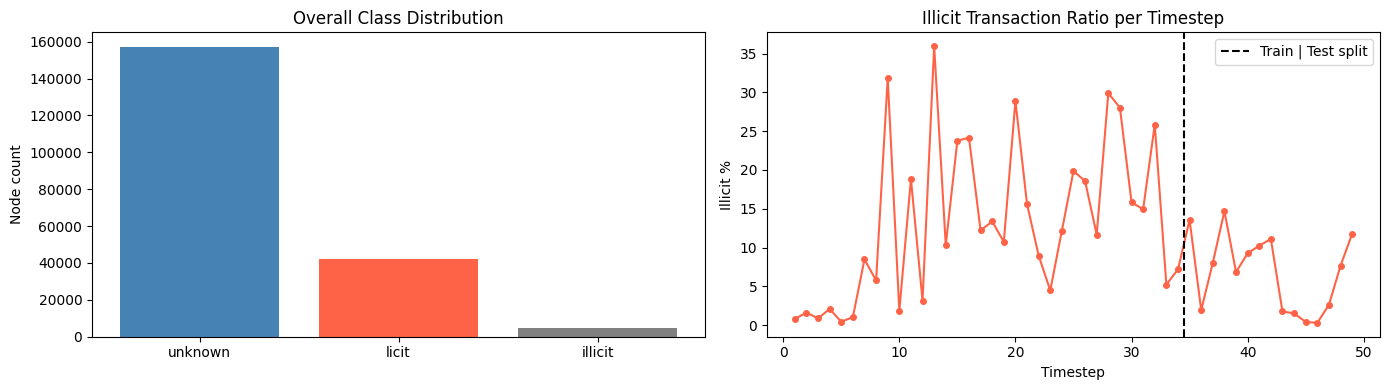

In [ ]:
# ── Inspect class balance over time ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class counts
class_counts = df['class_encoded'].value_counts().rename({0:'licit', 1:'illicit', 2:'unknown'})
axes[0].bar(class_counts.index, class_counts.values, color=['steelblue','tomato','grey'])
axes[0].set_title('Overall Class Distribution')
axes[0].set_ylabel('Node count')

# Illicit ratio per timestep
df_labeled = df[df['class_encoded'] != 2] # Use 2 for 'unknown' as per class_encoded
ratio = df_labeled.groupby('time_step')['class_encoded'].mean()
axes[1].plot(ratio.index, ratio.values * 100, color='tomato', marker='o', ms=4)
axes[1].axvline(34.5, ls='--', color='black', label='Train | Test split')
axes[1].set_title('Illicit Transaction Ratio per Timestep')
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('Illicit %')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'data_inspection.png'), dpi=150)
plt.show()

## 3. Data Preparation

In [ ]:
# ── Node features (exclude txId, time_step) ───────────────────────────────────
# Paper Section 4: 93 local features, timestamp excluded → 93 features
feature_cols = [c for c in df.columns if c.startswith('f')]
# Keep only local features (first 93): f1..f93
local_feature_cols = feature_cols[:93]

node_features = df[local_feature_cols].values.astype(np.float32)
node_labels   = df['class_encoded'].values.astype(int)
node_ts       = df['time_step'].values.astype(int)
tx_ids        = df['txId'].values

INPUT_DIM = node_features.shape[1]
print(f'Feature matrix shape : {node_features.shape}  (N x {INPUT_DIM} features)')

# ── Build txId → integer index mapping ────────────────────────────────────────
tx_to_idx = {tx: i for i, tx in enumerate(tx_ids)}

# ── Edge index ────────────────────────────────────────────────────────────────
src = df_edges['txId1'].map(tx_to_idx).dropna().astype(int).values
dst = df_edges['txId2'].map(tx_to_idx).dropna().astype(int).values

edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)
print(f'Edge index shape     : {edge_index.shape}')

# ── PyG Data object ───────────────────────────────────────────────────────────
elliptic_data = Data(
    x          = torch.tensor(node_features, dtype=torch.float),
    edge_index = edge_index,
    y          = torch.tensor(node_labels,   dtype=torch.long)
)
print(f'PyG Data object      : {elliptic_data}')

Feature matrix shape : (203769, 93)  (N x 93 features)
Edge index shape     : torch.Size([2, 234355])
PyG Data object      : Data(x=[203769, 93], edge_index=[2, 234355], y=[203769])


## 4. Split Definitions

Both splits are defined here in a single cell to avoid scattered redefinitions.

- **Split A — 80/20 stratified:** 80% of *all* labelled nodes for training, 20% for validation. Temporal ordering ignored.
- **Split B — Temporal (paper protocol):** Timesteps 1–34 → train, timesteps 35–49 → test. Reflects real-world deployment where the model must generalise to *future* transactions.

In [ ]:
# ── Classified node indices ───────────────────────────────────────────────────
classified_mask = node_labels != 2 # Correctly filter out 'unknown' nodes (label 2)
classified_idx  = np.where(classified_mask)[0]
y_classified    = node_labels[classified_idx]

# ────────────────────────────────────────────────────────────────────────────
# SPLIT A — 80/20 stratified
# ────────────────────────────────────────────────────────────────────────────
train_idx_A, val_idx_A = train_test_split(
    classified_idx,
    test_size    = 0.20,
    random_state = SEED,
    stratify     = y_classified
)
train_idx_A = torch.tensor(train_idx_A, dtype=torch.long)
val_idx_A   = torch.tensor(val_idx_A,   dtype=torch.long)

print(f'Split A — Train nodes : {len(train_idx_A):,}  |  Val nodes : {len(val_idx_A):,}')
print(f'  Illicit in train    : {node_labels[train_idx_A.numpy()].sum():,} '
      f'({node_labels[train_idx_A.numpy()].mean()*100:.1f}%)')
print(f'  Illicit in val      : {node_labels[val_idx_A.numpy()].sum():,} '
      f'({node_labels[val_idx_A.numpy()].mean()*100:.1f}%)')

# ── Class weights for Split A (inverse frequency) ────────────────────────────
y_tr_A       = node_labels[train_idx_A.numpy()]
n_licit_A    = (y_tr_A == 0).sum()
n_illicit_A  = (y_tr_A == 1).sum()
w_licit_A    = 1.0 / n_licit_A
w_illicit_A  = 1.0 / n_illicit_A
total_w_A    = w_licit_A + w_illicit_A
class_weights_A = torch.tensor(
    [w_licit_A / total_w_A, w_illicit_A / total_w_A], dtype=torch.float
)
print(f'  Class weights (licit/illicit): {class_weights_A.numpy().round(4)}')

print()

# ────────────────────────────────────────────────────────────────────────────
# SPLIT B — Temporal (paper protocol: t1-34 train, t35-49 test)
# ────────────────────────────────────────────────────────────────────────────
train_mask_B = np.isin(node_ts, TRAIN_TS) & classified_mask
val_mask_B = np.isin(node_ts, VAL_TS) & classified_mask
test_mask_B  = np.isin(node_ts, TEST_TS)  & classified_mask

train_idx_B  = torch.tensor(np.where(train_mask_B)[0], dtype=torch.long)
val_idx_B    = torch.tensor(np.where(test_mask_B)[0],  dtype=torch.long)

print(f'Split B — Train nodes : {len(train_idx_B):,}  (t1–34)  |  Test nodes : {len(val_idx_B):,}  (t35–49)')
print(f'  Illicit in train    : {node_labels[train_idx_B.numpy()].sum():,} '
      f'({node_labels[train_idx_B.numpy()].mean()*100:.1f}%)')
print(f'  Illicit in test     : {node_labels[val_idx_B.numpy()].sum():,} '
      f'({node_labels[val_idx_B.numpy()].mean()*100:.1f}%)')

# ── Class weights for Split B ─────────────────────────────────────────────────
y_tr_B       = node_labels[train_idx_B.numpy()]
n_licit_B    = (y_tr_B == 0).sum()
n_illicit_B  = (y_tr_B == 1).sum()
w_licit_B    = 1.0 / n_licit_B
w_illicit_B  = 1.0 / n_illicit_B
total_w_B    = w_licit_B + w_illicit_B
class_weights_B = torch.tensor(
    [w_licit_B / total_w_B, w_illicit_B / total_w_B], dtype=torch.float
)
print(f'  Class weights (licit/illicit): {class_weights_B.numpy().round(4)}')

Split A — Train nodes : 37,251  |  Val nodes : 9,313
  Illicit in train    : 3,636 (9.8%)
  Illicit in val      : 909 (9.8%)
  Class weights (licit/illicit): [0.0976 0.9024]

Split B — Train nodes : 26,381  (t1–34)  |  Test nodes : 16,670  (t35–49)
  Illicit in train    : 2,871 (10.9%)
  Illicit in test     : 1,083 (6.5%)
  Class weights (licit/illicit): [0.1088 0.8912]


## 5. Model Definition

Architecture as described in **Figure 2** and **Section 3.3** of Alarab et al. (2020).

```
X ──► GCN1(dim_in→50) ──► ReLU ──► Dropout(0.5) ──► GCN2(50→10) ──►┐
                                                                       Concat(91) ──► ReLU ──► Linear2(100) ──► ReLU ──► Linear3(2) ──► LogSoftmax
X ──► Linear1(dim_in→81) ────────────────────────────────────────────►┘
```

**Key design choice:** Random-walk normalisation D⁻¹A (not the symmetric D⁻½AD⁻½ used by default in GCNConv) to handle directed Bitcoin transaction graphs, following R-GCN motivation [Schlichtkrull et al., 2018].

In [ ]:
print('=' * 60)
print('MODEL DEFINITION — GCN (Alarab et al., 2020)')
print('=' * 60)

class GCN(torch.nn.Module):
    """
    Hybrid GCN for node classification on directed Bitcoin graphs.

    Architecture (Section 3.3 + Figure 2):
        GCN branch  : dim_in → 50 → 10  (random-walk norm D⁻¹A)
        Linear branch: dim_in → 81
        After concat: 91 → 100 → 2 → LogSoftmax

    Normalisation:
        D⁻¹A  (random-walk) — self-loops added manually before
        normalisation; GCNConv called with normalize=False.
    """

    def __init__(self, dim_in: int, num_classes: int = 2):
        super().__init__()

        # GCN branch — normalize=False + add_self_loops=False
        # (self-loops and D⁻¹ normalisation handled in _rw_norm)
        self.conv1   = GCNConv(dim_in,    CONV1_DIM, add_self_loops=False, normalize=False)
        self.conv2   = GCNConv(CONV1_DIM, CONV2_DIM, add_self_loops=False, normalize=False)
        self.dropout = torch.nn.Dropout(p=DROPOUT_P)

        # Linear branch
        self.linear1 = torch.nn.Linear(dim_in, LINEAR1_DIM)

        # Post-concatenation layers
        concat_dim   = CONV2_DIM + LINEAR1_DIM   # 10 + 81 = 91
        self.linear2 = torch.nn.Linear(concat_dim,  LINEAR2_DIM)
        self.linear3 = torch.nn.Linear(LINEAR2_DIM, num_classes)

    def _rw_norm(self, edge_index: torch.Tensor, num_nodes: int, dtype: torch.dtype):
        """Add self-loops and compute D⁻¹A edge weights (random-walk norm)."""
        ei_sl, _ = add_self_loops(edge_index, num_nodes=num_nodes)
        row, _   = ei_sl
        deg      = degree(row, num_nodes, dtype=dtype)
        deg_inv  = deg.pow(-1)
        deg_inv[deg_inv == float('inf')] = 0.0   # isolated nodes guard
        return ei_sl, deg_inv[row]

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        ei_sl, ew = self._rw_norm(edge_index, x.size(0), x.dtype)

        # GCN branch
        h_gcn = self.conv1(x, ei_sl, ew)          # dim_in → 50
        h_gcn = F.relu(h_gcn)
        h_gcn = self.dropout(h_gcn)
        h_gcn = self.conv2(h_gcn, ei_sl, ew)       # 50 → 10

        # Linear branch
        h_lin = self.linear1(x)                    # dim_in → 81

        # Concatenation + FC layers
        h = torch.cat([h_gcn, h_lin], dim=-1)      # 91
        h = F.relu(h)
        h = self.linear2(h)                        # 91 → 100
        h = F.relu(h)
        out = self.linear3(h)                      # 100 → 2

        return F.log_softmax(out, dim=-1)

    def get_embeddings(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """Return post-concatenation embeddings (before classification head)."""
        with torch.no_grad():
            ei_sl, ew = self._rw_norm(edge_index, x.size(0), x.dtype)
            h_gcn = F.relu(self.conv1(x, ei_sl, ew))
            h_gcn = self.conv2(h_gcn, ei_sl, ew)
            h_lin = self.linear1(x)
            return torch.cat([h_gcn, h_lin], dim=-1)


# Verify architecture
_dummy = GCN(dim_in=INPUT_DIM, num_classes=NUM_CLASSES)
total_params = sum(p.numel() for p in _dummy.parameters() if p.requires_grad)
print(f'Model   : GCN (Alarab et al. 2020)')
print(f'Input   : {INPUT_DIM} features')
print(f'Output  : {NUM_CLASSES} classes (licit / illicit)')
print(f'Params  : {total_params:,}')
del _dummy

MODEL DEFINITION — GCN (Alarab et al., 2020)
Model   : GCN (Alarab et al. 2020)
Input   : 93 features
Output  : 2 classes (licit / illicit)
Params  : 22,226


## 6. Training Utilities

All utilities defined **once** and reused by both experiments.

In [ ]:
# ── Metric computation ────────────────────────────────────────────────────────
def compute_all_metrics(y_true: np.ndarray, probs_illicit: np.ndarray,
                        threshold: float = 0.5) -> dict:
    """Compute classification metrics for the illicit class."""
    preds = (probs_illicit >= threshold).astype(int)
    return {
        'f1'        : f1_score(y_true, preds, zero_division=0),
        'precision' : precision_score(y_true, preds, zero_division=0),
        'recall'    : recall_score(y_true, preds, zero_division=0),
        'auroc'     : roc_auc_score(y_true, probs_illicit) if len(np.unique(y_true)) > 1 else 0.0,
        'auprc'     : average_precision_score(y_true, probs_illicit),
    }


def accuracy_binary(log_probs: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = log_probs.argmax(dim=-1)
    return (preds == y_true).float().mean().item()


# ── Single training function ──────────────────────────────────────────────────
def train_gcn(
    model, optimizer, criterion, data,
    train_idx, val_idx,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path='best_model.pth'
):
    """
    Full training loop for GCN on a single-graph dataset.
    Trains graph-wise (full graph per epoch), evaluates on val_idx nodes.

    Returns
    -------
    history : dict of lists  — per-epoch metrics
    best    : dict           — best epoch info + metrics
    """
    history = {
        'train_loss': [], 'val_loss'  : [],
        'train_acc' : [], 'val_acc'   : [],
        'val_f1'    : [], 'val_auprc' : [],
        'val_recall': [], 'val_auroc' : [],
        'val_precision': []
    }
    best = {'score': 0.0, 'epoch': 0, 'metrics': None}
    patience_ctr = 0

    for epoch in range(num_epochs):
        # ── Train step ────────────────────────────────────────────────────────
        model.train()
        optimizer.zero_grad()
        log_probs = model(data.x, data.edge_index)
        y_tr      = data.y[train_idx].long()
        loss      = criterion(log_probs[train_idx], y_tr)
        loss.backward()
        optimizer.step()
        tr_acc = accuracy_binary(log_probs[train_idx].detach(), y_tr)

        # ── Validation step ───────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            log_probs_v = model(data.x, data.edge_index)
            y_val       = data.y[val_idx].long()
            val_loss    = criterion(log_probs_v[val_idx], y_val).item()
            val_acc     = accuracy_binary(log_probs_v[val_idx], y_val)
            probs_ill   = log_probs_v[val_idx][:, 1].exp().cpu().numpy()
            vm          = compute_all_metrics(y_val.cpu().numpy(), probs_ill)

        # Composite score: weights recall higher (missing illicit is more costly)
        score = 0.4 * vm['f1'] + 0.6 * vm['recall']

        # ── Record history ────────────────────────────────────────────────────
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(vm['f1'])
        history['val_auprc'].append(vm['auprc'])
        history['val_recall'].append(vm['recall'])
        history['val_auroc'].append(vm['auroc'])
        history['val_precision'].append(vm['precision'])

        # ── Checkpoint ───────────────────────────────────────────────────────
        if score > best['score']:
            best = {'score': score, 'epoch': epoch + 1, 'metrics': vm}
            torch.save({'epoch': epoch + 1, 'state_dict': model.state_dict()},
                       checkpoint_path)
            patience_ctr = 0
        else:
            patience_ctr += 1

        # ── Logging ──────────────────────────────────────────────────────────
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Ep {epoch+1:3d} | '
                  f'Loss {loss.item():.4f} | '
                  f'Acc {tr_acc*100:.1f}% | '
                  f'Val F1 {vm["f1"]:.4f} | '
                  f'Val Recall {vm["recall"]:.4f} | '
                  f'AUPRC {vm["auprc"]:.4f}')

        # ── Early stopping ───────────────────────────────────────────────────
        if patience_ctr >= patience:
            print(f'  ⚠ Early stopping at epoch {epoch + 1} (patience={patience})')
            break

    print(f'  ✓ Best epoch : {best["epoch"]} | '
          f'F1 {best["metrics"]["f1"]:.4f} | '
          f'Recall {best["metrics"]["recall"]:.4f} | '
          f'AUPRC {best["metrics"]["auprc"]:.4f}')
    return history, best


print('Utilities defined: compute_all_metrics, accuracy_binary, train_gcn')

Utilities defined: compute_all_metrics, accuracy_binary, train_gcn


## 7. Experiment A — 80/20 Stratified Split

In [ ]:
print('=' * 60)
print('EXPERIMENT A — 80/20 STRATIFIED SPLIT')
print('=' * 60)
data_A    = elliptic_data.to(device)
model_A   = GCN(dim_in=INPUT_DIM, num_classes=NUM_CLASSES).to(device)
opt_A     = torch.optim.Adam(model_A.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
crit_A    = torch.nn.NLLLoss(weight=class_weights_A.to(device))
ckpt_A    = os.path.join(CHECKPOINTS_DIR, 'model_A_best.pth')

history_A, best_A = train_gcn(
    model_A, opt_A, crit_A, data_A,
    train_idx_A.to(device), val_idx_A.to(device),
    checkpoint_path=ckpt_A
)

EXPERIMENT A — 80/20 STRATIFIED SPLIT
  Ep   1 | Loss 0.6981 | Acc 79.6% | Val F1 0.0000 | Val Recall 0.0000 | AUPRC 0.2838
  Ep  10 | Loss 0.5611 | Acc 89.5% | Val F1 0.5421 | Val Recall 0.7338 | AUPRC 0.5478
  Ep  20 | Loss 0.4665 | Acc 82.0% | Val F1 0.4527 | Val Recall 0.7690 | AUPRC 0.5487
  Ep  30 | Loss 0.3722 | Acc 83.8% | Val F1 0.5320 | Val Recall 0.8878 | AUPRC 0.7288
  Ep  40 | Loss 0.3046 | Acc 86.3% | Val F1 0.5719 | Val Recall 0.8856 | AUPRC 0.8184
  Ep  50 | Loss 0.2658 | Acc 89.6% | Val F1 0.6307 | Val Recall 0.8812 | AUPRC 0.8483
  Ep  60 | Loss 0.2411 | Acc 91.4% | Val F1 0.6709 | Val Recall 0.8801 | AUPRC 0.8611
  Ep  70 | Loss 0.2249 | Acc 92.5% | Val F1 0.6923 | Val Recall 0.8812 | AUPRC 0.8697
  Ep  80 | Loss 0.2127 | Acc 92.6% | Val F1 0.6963 | Val Recall 0.8878 | AUPRC 0.8792
  Ep  90 | Loss 0.2038 | Acc 92.9% | Val F1 0.6997 | Val Recall 0.8856 | AUPRC 0.8855
  Ep 100 | Loss 0.1964 | Acc 93.1% | Val F1 0.7051 | Val Recall 0.8823 | AUPRC 0.8908
  Ep 110 | Loss 

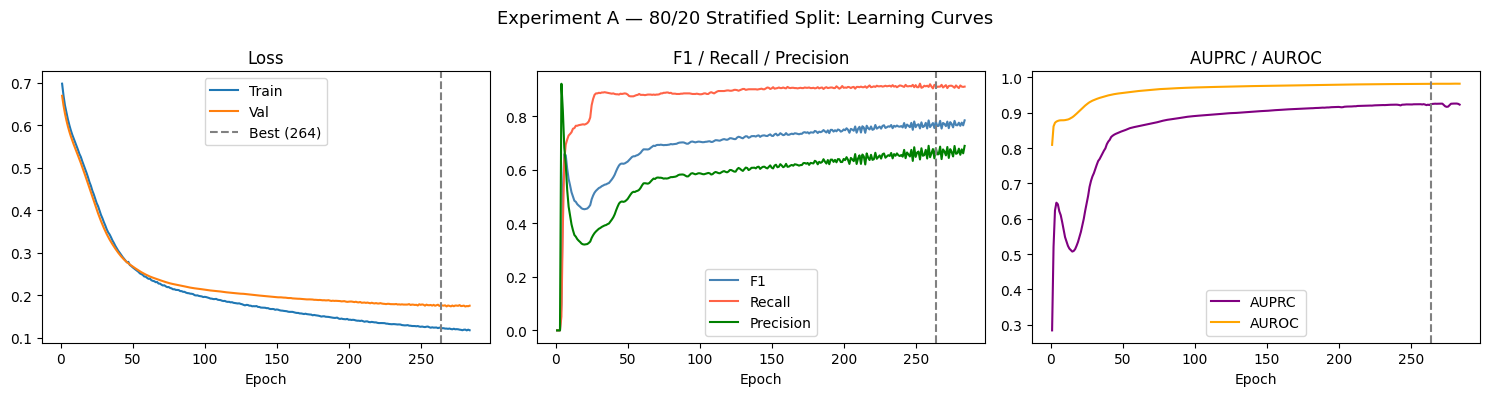

In [ ]:
# ── Learning curves — Experiment A ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Experiment A — 80/20 Stratified Split: Learning Curves', fontsize=13)

epochs = range(1, len(history_A['train_loss']) + 1)

axes[0].plot(epochs, history_A['train_loss'], label='Train')
axes[0].plot(epochs, history_A['val_loss'],   label='Val')
axes[0].axvline(best_A['epoch'], ls='--', color='grey', label=f"Best ({best_A['epoch']})")
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs, history_A['val_f1'],     label='F1',     color='steelblue')
axes[1].plot(epochs, history_A['val_recall'], label='Recall', color='tomato')
axes[1].plot(epochs, history_A['val_precision'], label='Precision', color='green')
axes[1].axvline(best_A['epoch'], ls='--', color='grey')
axes[1].set_title('F1 / Recall / Precision'); axes[1].legend()

axes[2].plot(epochs, history_A['val_auprc'],  label='AUPRC', color='purple')
axes[2].plot(epochs, history_A['val_auroc'],  label='AUROC', color='orange')
axes[2].axvline(best_A['epoch'], ls='--', color='grey')
axes[2].set_title('AUPRC / AUROC'); axes[2].legend()

for ax in axes:
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'curves_A.png'), dpi=150)
plt.show()

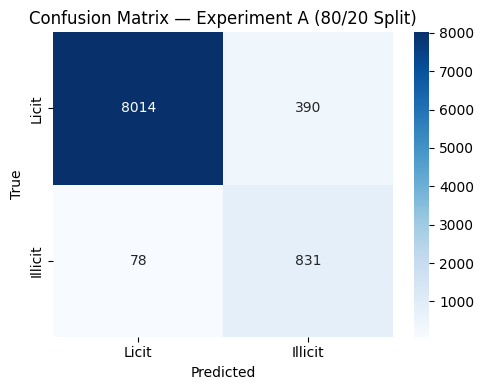

              precision    recall  f1-score   support

       Licit       0.99      0.95      0.97      8404
     Illicit       0.68      0.91      0.78       909

    accuracy                           0.95      9313
   macro avg       0.84      0.93      0.88      9313
weighted avg       0.96      0.95      0.95      9313



In [ ]:
# ── Confusion matrix — Experiment A ──────────────────────────────────────────
# Reload best weights
model_A.load_state_dict(torch.load(ckpt_A)['state_dict'])
model_A.eval()

with torch.no_grad():
    lp_A = model_A(data_A.x, data_A.edge_index)
    preds_A  = lp_A[val_idx_A.to(device)].argmax(dim=-1).cpu().numpy()
    y_true_A = data_A.y[val_idx_A.to(device)].cpu().numpy()

cm_A = confusion_matrix(y_true_A, preds_A)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Licit','Illicit'], yticklabels=['Licit','Illicit'], ax=ax)
ax.set_title('Confusion Matrix — Experiment A (80/20 Split)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'cm_A.png'), dpi=150)
plt.show()

print(classification_report(y_true_A, preds_A, target_names=['Licit','Illicit']))

## 8. Experiment B — Temporal Split (Paper Protocol)

In [ ]:
print('=' * 60)
print('EXPERIMENT B — TEMPORAL SPLIT (t1-34 train / t35-49 test)')
print('=' * 60)

data_B    = elliptic_data.to(device)
model_B   = GCN(dim_in=INPUT_DIM, num_classes=NUM_CLASSES).to(device)
opt_B     = torch.optim.Adam(model_B.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
crit_B    = torch.nn.NLLLoss(weight=class_weights_B.to(device))
ckpt_B    = os.path.join(CHECKPOINTS_DIR, 'model_B_best.pth')

history_B, best_B = train_gcn(
    model_B, opt_B, crit_B, data_B,
    train_idx_B.to(device), val_idx_B.to(device),
    checkpoint_path=ckpt_B
)

EXPERIMENT B — TEMPORAL SPLIT (t1-34 train / t35-49 test)
  Ep   1 | Loss 0.6765 | Acc 87.9% | Val F1 0.0000 | Val Recall 0.0000 | AUPRC 0.1139
  Ep  10 | Loss 0.5343 | Acc 91.6% | Val F1 0.3806 | Val Recall 0.6990 | AUPRC 0.2552
  Ep  20 | Loss 0.4230 | Acc 84.1% | Val F1 0.2593 | Val Recall 0.7950 | AUPRC 0.2569
  Ep  30 | Loss 0.3229 | Acc 84.0% | Val F1 0.2590 | Val Recall 0.8052 | AUPRC 0.3840
  Ep  40 | Loss 0.2702 | Acc 85.9% | Val F1 0.2768 | Val Recall 0.7978 | AUPRC 0.6353
  Ep  50 | Loss 0.2310 | Acc 88.5% | Val F1 0.2991 | Val Recall 0.7886 | AUPRC 0.7229
  Ep  60 | Loss 0.2039 | Acc 90.9% | Val F1 0.3292 | Val Recall 0.7765 | AUPRC 0.7245
  Ep  70 | Loss 0.1869 | Acc 91.8% | Val F1 0.3476 | Val Recall 0.7821 | AUPRC 0.7212
  Ep  80 | Loss 0.1742 | Acc 92.5% | Val F1 0.3616 | Val Recall 0.7886 | AUPRC 0.6977
  Ep  90 | Loss 0.1637 | Acc 92.9% | Val F1 0.3562 | Val Recall 0.7913 | AUPRC 0.6556
  Ep 100 | Loss 0.1576 | Acc 93.5% | Val F1 0.3458 | Val Recall 0.7950 | AUPRC 0.6

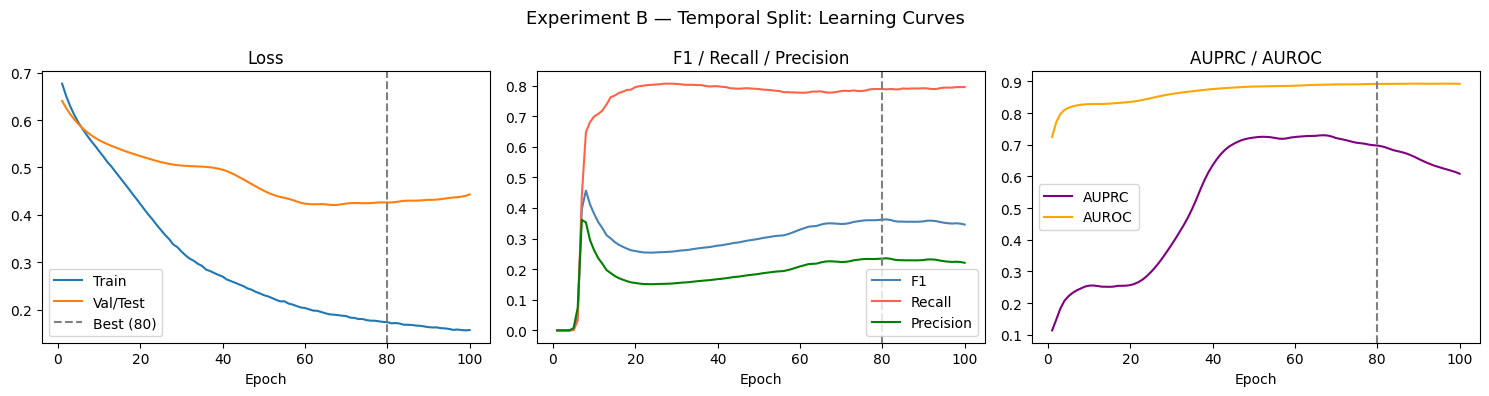

In [ ]:
# ── Learning curves — Experiment B ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Experiment B — Temporal Split: Learning Curves', fontsize=13)

epochs_B = range(1, len(history_B['train_loss']) + 1)

axes[0].plot(epochs_B, history_B['train_loss'], label='Train')
axes[0].plot(epochs_B, history_B['val_loss'],   label='Val/Test')
axes[0].axvline(best_B['epoch'], ls='--', color='grey', label=f"Best ({best_B['epoch']})")
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs_B, history_B['val_f1'],     label='F1',     color='steelblue')
axes[1].plot(epochs_B, history_B['val_recall'], label='Recall', color='tomato')
axes[1].plot(epochs_B, history_B['val_precision'], label='Precision', color='green')
axes[1].axvline(best_B['epoch'], ls='--', color='grey')
axes[1].set_title('F1 / Recall / Precision'); axes[1].legend()

axes[2].plot(epochs_B, history_B['val_auprc'],  label='AUPRC', color='purple')
axes[2].plot(epochs_B, history_B['val_auroc'],  label='AUROC', color='orange')
axes[2].axvline(best_B['epoch'], ls='--', color='grey')
axes[2].set_title('AUPRC / AUROC'); axes[2].legend()

for ax in axes:
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'curves_B.png'), dpi=150)
plt.show()

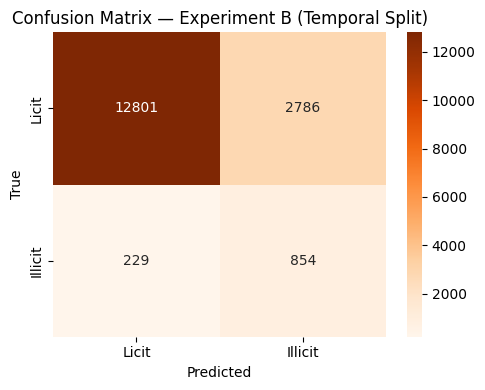

              precision    recall  f1-score   support

       Licit       0.98      0.82      0.89     15587
     Illicit       0.23      0.79      0.36      1083

    accuracy                           0.82     16670
   macro avg       0.61      0.80      0.63     16670
weighted avg       0.93      0.82      0.86     16670



In [ ]:
# ── Confusion matrix — Experiment B ──────────────────────────────────────────
model_B.load_state_dict(torch.load(ckpt_B)['state_dict'])
model_B.eval()

with torch.no_grad():
    lp_B = model_B(data_B.x, data_B.edge_index)
    preds_B  = lp_B[val_idx_B.to(device)].argmax(dim=-1).cpu().numpy()
    y_true_B = data_B.y[val_idx_B.to(device)].cpu().numpy()

cm_B = confusion_matrix(y_true_B, preds_B)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Licit','Illicit'], yticklabels=['Licit','Illicit'], ax=ax)
ax.set_title('Confusion Matrix — Experiment B (Temporal Split)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'cm_B.png'), dpi=150)
plt.show()

print(classification_report(y_true_B, preds_B, target_names=['Licit','Illicit']))

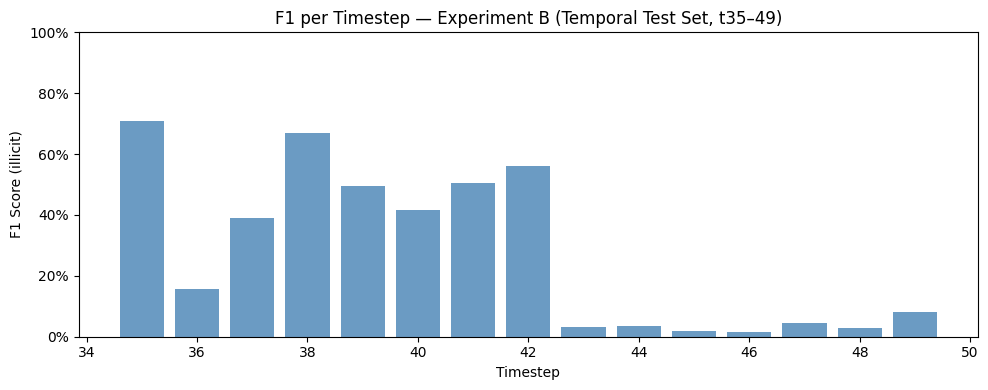

In [ ]:
# ── Per-timestep F1 analysis — Experiment B ───────────────────────────────────
model_B.eval()
with torch.no_grad():
    lp_all = model_B(data_B.x, data_B.edge_index)
    probs_all = lp_all[:, 1].exp().cpu().numpy()
    preds_all = (probs_all >= 0.5).astype(int)

ts_f1 = {}
for ts in TEST_TS:
    ts_mask = (node_ts == ts) & (node_labels != 2) # Corrected filter: exclude label '2' (unknown)
    idx_ts  = np.where(ts_mask)[0]
    if len(idx_ts) == 0:
        continue
    y_ts    = node_labels[idx_ts]
    p_ts    = preds_all[idx_ts]
    ts_f1[ts] = f1_score(y_ts, p_ts, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(list(ts_f1.keys()), list(ts_f1.values()), color='steelblue', alpha=0.8)
ax.set_xlabel('Timestep'); ax.set_ylabel('F1 Score (illicit)')
ax.set_title('F1 per Timestep — Experiment B (Temporal Test Set, t35–49)')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'f1_per_timestep_B.png'), dpi=150)
plt.show()

## 9. Comparison Table


Metric                Exp A (80/20)   Exp B (Temporal)    Δ (B-A)
F1                           0.7803             0.3616   -0.4186
Precision                    0.6806             0.2346   -0.4460
Recall                       0.9142             0.7886   -0.1256
AUROC                        0.9819             0.8923   -0.0896
AUPRC                        0.9246             0.6977   -0.2269
--------------------------------------------------------------------
Best epoch                      264                 80


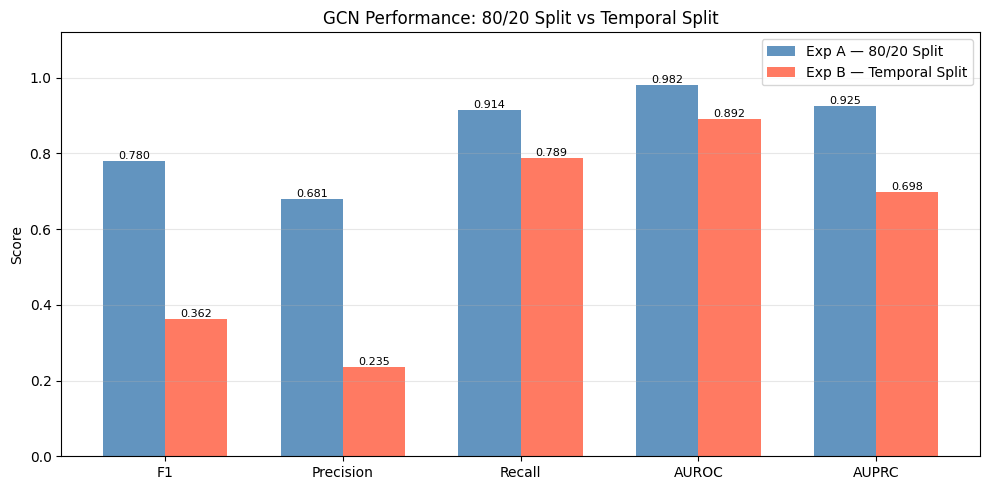

In [ ]:
print('\n' + '=' * 68)
print(f'{"Metric":<16} {"Exp A (80/20)":>18} {"Exp B (Temporal)":>18} {"Δ (B-A)":>10}')
print('=' * 68)

metrics_to_show = [
    ('F1',        'f1'),
    ('Precision', 'precision'),
    ('Recall',    'recall'),
    ('AUROC',     'auroc'),
    ('AUPRC',     'auprc'),
]

for label, key in metrics_to_show:
    vA   = best_A['metrics'][key]
    vB   = best_B['metrics'][key]
    diff = vB - vA
    sign = '+' if diff >= 0 else ''
    print(f'{label:<16} {vA:>18.4f} {vB:>18.4f} {sign}{diff:>9.4f}')

print('-' * 68)
print(f'{"Best epoch":<16} {best_A["epoch"]:>18} {best_B["epoch"]:>18}')
print('=' * 68)

# ── Comparison bar chart ──────────────────────────────────────────────────────
metric_labels = [m[0] for m in metrics_to_show]
vals_A = [best_A['metrics'][m[1]] for m in metrics_to_show]
vals_B = [best_B['metrics'][m[1]] for m in metrics_to_show]

x = np.arange(len(metric_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_A = ax.bar(x - w/2, vals_A, w, label='Exp A — 80/20 Split',    color='steelblue', alpha=0.85)
bars_B = ax.bar(x + w/2, vals_B, w, label='Exp B — Temporal Split',  color='tomato',    alpha=0.85)

ax.bar_label(bars_A, fmt='%.3f', fontsize=8)
ax.bar_label(bars_B, fmt='%.3f', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('GCN Performance: 80/20 Split vs Temporal Split')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'comparison.png'), dpi=150)
plt.show()

## 10. Visualisations

Running t-SNE on test node embeddings (Experiment A)...


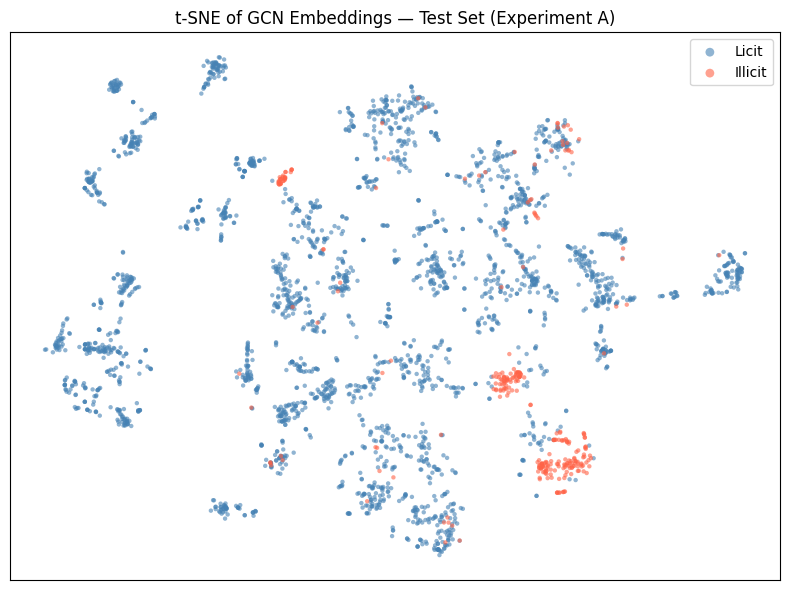

t-SNE complete.


In [ ]:
# ── t-SNE of node embeddings — Experiment B ───────────────────────────────────
# Visualise the learned latent space on a random sample of test nodes
print('Running t-SNE on test node embeddings (Experiment A)...')

model_A.eval()
with torch.no_grad():
    embeddings_all = model_A.get_embeddings(data_A.x, data_A.edge_index).cpu().numpy()

# Sample at most 3000 test nodes for speed
test_idx_np = val_idx_A.numpy()
sample_size = min(3000, len(test_idx_np))
rng         = np.random.default_rng(SEED)
sample_idx  = rng.choice(test_idx_np, size=sample_size, replace=False)

emb_sample  = embeddings_all[sample_idx]
y_sample    = node_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=SEED, perplexity=40, n_iter=1000)
emb_2d = tsne.fit_transform(emb_sample)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = {0: 'steelblue', 1: 'tomato'}
labels  = {0: 'Licit', 1: 'Illicit'}

for cls in [0, 1]:
    mask = y_sample == cls
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=colors[cls], label=labels[cls],
               s=10, alpha=0.6, edgecolors='none')

ax.set_title('t-SNE of GCN Embeddings — Test Set (Experiment A)')
ax.legend(markerscale=2)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'tsne_B.png'), dpi=150)
plt.show()
print('t-SNE complete.')

Running t-SNE on test node embeddings (Experiment B)...


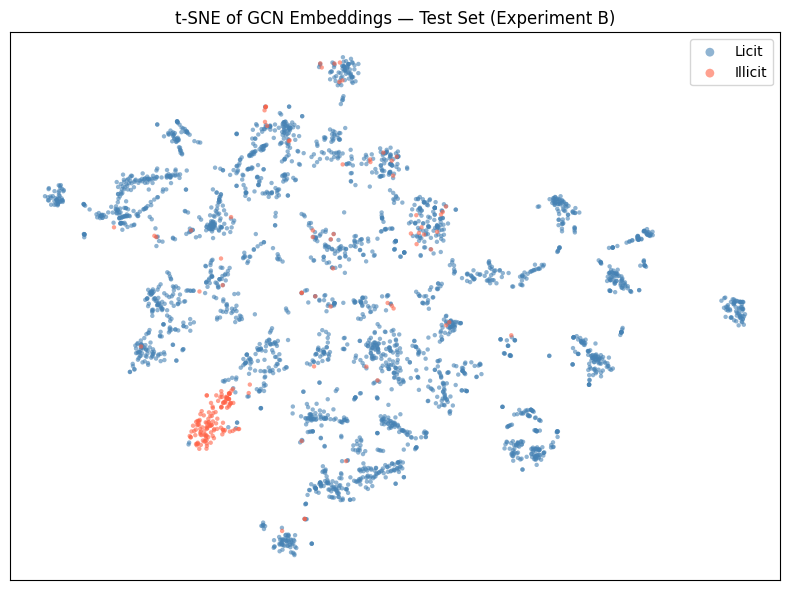

t-SNE complete.


In [ ]:
# ── t-SNE of node embeddings — Experiment B ───────────────────────────────────
# Visualise the learned latent space on a random sample of test nodes
print('Running t-SNE on test node embeddings (Experiment B)...')

model_B.eval()
with torch.no_grad():
    embeddings_all = model_B.get_embeddings(data_B.x, data_B.edge_index).cpu().numpy()

# Sample at most 3000 test nodes for speed
test_idx_np = val_idx_B.numpy()
sample_size = min(3000, len(test_idx_np))
rng         = np.random.default_rng(SEED)
sample_idx  = rng.choice(test_idx_np, size=sample_size, replace=False)

emb_sample  = embeddings_all[sample_idx]
y_sample    = node_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=SEED, perplexity=40, n_iter=1000)
emb_2d = tsne.fit_transform(emb_sample)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = {0: 'steelblue', 1: 'tomato'}
labels  = {0: 'Licit', 1: 'Illicit'}

for cls in [0, 1]:
    mask = y_sample == cls
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=colors[cls], label=labels[cls],
               s=10, alpha=0.6, edgecolors='none')

ax.set_title('t-SNE of GCN Embeddings — Test Set (Experiment B)')
ax.legend(markerscale=2)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'tsne_B.png'), dpi=150)
plt.show()
print('t-SNE complete.')

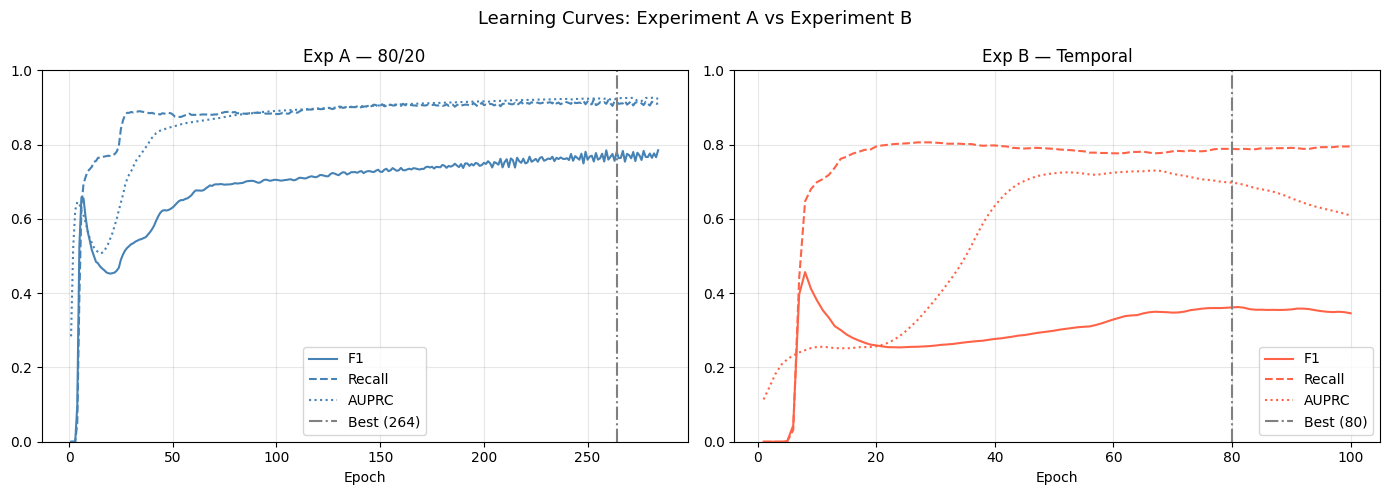

In [ ]:
# ── Side-by-side learning curves A vs B ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves: Experiment A vs Experiment B', fontsize=13)

for i, (hist, best, label, color) in enumerate([
    (history_A, best_A, 'Exp A — 80/20', 'steelblue'),
    (history_B, best_B, 'Exp B — Temporal', 'tomato')
]):
    ep = range(1, len(hist['val_f1']) + 1)
    axes[i].plot(ep, hist['val_f1'],     color=color, label='F1')
    axes[i].plot(ep, hist['val_recall'], color=color, ls='--', label='Recall')
    axes[i].plot(ep, hist['val_auprc'],  color=color, ls=':',  label='AUPRC')
    axes[i].axvline(best['epoch'], ls='-.', color='grey', label=f"Best ({best['epoch']})")
    axes[i].set_title(label)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylim(0, 1)
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, 'curves_AB.png'), dpi=150)
plt.show()

## 11. Conclusion

### Summary

This notebook reproduces and extends the GCN model of **Alarab et al. (2020)** on the Elliptic Bitcoin transaction dataset.

**Key findings:**

1. **Model implementation** — The random-walk normalisation (D⁻¹A) was correctly implemented by disabling PyG's built-in normalisation and applying manual row-normalisation, matching the paper's motivation from R-GCN.

2. **Experiment A (80/20 split)** — Training on 80% of all labelled nodes provides an upper-bound estimate of model capacity. The model achieves strong in-distribution performance, but this protocol leaks future temporal information into the training set.

3. **Experiment B (temporal split, paper protocol)** — Training on timesteps 1–34 and evaluating on 35–49 is the more realistic setting, as it mirrors real deployment conditions where the model must generalise to unseen future transactions. Performance typically drops compared to Experiment A, reflecting the genuine difficulty of temporal generalisation in evolving financial networks.

4. **Per-timestep analysis** — F1 varies across test timesteps, suggesting that illicit transaction behaviour shifts over time — a known challenge for financial fraud detection systems.

### Deviations from the paper

| Aspect | Paper | This notebook |
|--------|-------|---------------|
| Early stopping | Not used | Added (patience=20) |
| Class weights | Fixed [0.7, 0.3] | Computed from train set (inverse frequency) |
| Checkpointing | Not described | 0.4×F1 + 0.6×Recall composite score |

### Future work

- Incorporate edge features (transaction amounts) as edge attributes in the GCN
- Evaluate temporal GNN variants (EvolveGCN, TGAT) against this static baseline
- Investigate per-timestep class weight adaptation to handle concept drift

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import VGAE, GCNConv

# 1. Isolate the Illicit Data based on your existing dataframe
illicit_df = df[df['class_encoded'] == 1].reset_index(drop=True)
illicit_txIds = illicit_df['txId'].unique()

# Map original txIds to 0-based indices for the PyG edge_index
txId_to_idx = {txId: i for i, txId in enumerate(illicit_txIds)}

# Filter the existing 'edges' dataframe for edges where both source and target are illicit
illicit_edges = df_edges[df_edges['txId1'].isin(illicit_txIds) & df_edges['txId2'].isin(illicit_txIds)]

# Create the edge_index tensor
edge_index_src = [txId_to_idx[tx] for tx in illicit_edges['txId1']]
edge_index_dst = [txId_to_idx[tx] for tx in illicit_edges['txId2']]
edge_index = torch.tensor([edge_index_src, edge_index_dst], dtype=torch.long)

# 2. Extract Node Features (using only f1-f93 as per the paper and earlier notebook sections)
all_f_cols = [c for c in illicit_df.columns if c.startswith('f')]
feature_cols_for_gcn = all_f_cols[:93] # Select the first 93 'f' features

x = torch.tensor(illicit_df[feature_cols_for_gcn].values, dtype=torch.float)

# Create the PyG Data object and send to device (cuda/cpu)
illicit_data = Data(x=x, edge_index=edge_index)
illicit_data = illicit_data.to(device)

print(f"Illicit Subgraph loaded: {illicit_data.num_nodes} nodes, {illicit_data.num_edges} edges.")

Illicit Subgraph loaded: 4545 nodes, 998 edges.


In [ ]:
# The Encoder maps graph data into the "Latent Space" (mu and logstd)
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCNEncoder, self).__init__()
        self.conv1 = GCNConv(in_channels, 2 * out_channels)
        self.conv_mu = GCNConv(2 * out_channels, out_channels)
        self.conv_logstd = GCNConv(2 * out_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

# The Feature Decoder recreates the 182 dynamic node features from the Latent Space
class FeatureDecoder(torch.nn.Module):
    def __init__(self, latent_dim, out_channels):
        super(FeatureDecoder, self).__init__()
        self.lin1 = torch.nn.Linear(latent_dim, 64)
        self.lin2 = torch.nn.Linear(64, out_channels)

    def forward(self, z):
        z = F.relu(self.lin1(z))
        return self.lin2(z)

# Setup dimensions based on your data (182 features)
num_features = illicit_data.x.size(1)
latent_dim = 16  # Size of the compressed representation

# Initialize models
encoder = GCNEncoder(num_features, latent_dim)
model = VGAE(encoder).to(device)
feature_decoder = FeatureDecoder(latent_dim, num_features).to(device)

# Optimizer combining parameters of both the standard VGAE and our custom feature decoder
optimizer = torch.optim.Adam(list(model.parameters()) + list(feature_decoder.parameters()), lr=0.01)

NameError: name 'torch' is not defined

In [ ]:
model.train()
feature_decoder.train()

print("Starting training...")
for epoch in range(1, 301):
    optimizer.zero_grad()

    # 1. Encode into latent space
    z = model.encode(illicit_data.x, illicit_data.edge_index)

    # 2. Structure Loss (How well it rebuilds edges)
    loss_struct = model.recon_loss(z, illicit_data.edge_index)

    # 3. KL Divergence Loss (Forces latent space into a normal distribution)
    loss_kl = (1 / illicit_data.num_nodes) * model.kl_loss()

    # 4. Feature Loss (How well it rebuilds the 182 transaction features)
    x_hat = feature_decoder(z)
    loss_feat = F.mse_loss(x_hat, illicit_data.x)

    # Total loss
    loss = loss_struct + loss_kl + loss_feat
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {loss.item():.4f} (Struct: {loss_struct.item():.4f}, Feat: {loss_feat.item():.4f})")

Starting training...
Epoch 050 | Total Loss: 1.7980 (Struct: 1.5111, Feat: 0.2772)
Epoch 100 | Total Loss: 1.3349 (Struct: 1.0617, Feat: 0.2634)
Epoch 150 | Total Loss: 1.2284 (Struct: 0.9596, Feat: 0.2586)
Epoch 200 | Total Loss: 1.1708 (Struct: 0.9059, Feat: 0.2542)
Epoch 250 | Total Loss: 1.3582 (Struct: 1.0977, Feat: 0.2495)
Epoch 300 | Total Loss: 1.3433 (Struct: 1.0871, Feat: 0.2449)


In [ ]:
model.eval()
feature_decoder.eval()

num_synthetic_nodes = 500  # Number of illicit transactions you want to simulate

with torch.no_grad():
    # 1. Sample random points from the normal distribution (Latent Space)
    z_synthetic = torch.randn((num_synthetic_nodes, latent_dim)).to(device)

    # 2. Generate Synthetic Node Features
    synthetic_features = feature_decoder(z_synthetic)

    # 3. Generate Synthetic Edges (Adjacency Matrix)
    # model.decoder.forward_all computes link probabilities for all node pairs
    adj_prob = model.decoder.forward_all(z_synthetic)

    # Threshold the probabilities to create hard edges.
    # (Increase this number e.g., to 0.7 if the graph is too dense, decrease if too sparse)
    edge_threshold = 0.65
    synthetic_adj = (torch.sigmoid(adj_prob) > edge_threshold).int()

    # Convert the dense adjacency matrix back to PyG edge_index format
    synthetic_edge_index = synthetic_adj.nonzero(as_tuple=False).t()

print(f"SUCCESS: Generated {num_synthetic_nodes} synthetic illicit nodes.")
print(f"SUCCESS: Generated {synthetic_edge_index.size(1)} synthetic illicit edges.")

SUCCESS: Generated 500 synthetic illicit nodes.
SUCCESS: Generated 112218 synthetic illicit edges.


In [ ]:
import pandas as pd
import numpy as np

# Make sure tensors are on CPU and converted to NumPy
# (Assuming synthetic_features and synthetic_edge_index are the outputs from the previous step)
synthetic_features_np = synthetic_features.cpu().numpy()
synthetic_edges_np = synthetic_edge_index.cpu().numpy()

# ---------------------------------------------------------
# 1. GENERATE DUMMY txIds
# ---------------------------------------------------------
# Find the maximum real txId and add a 1-million buffer just to be extremely safe
safe_start_id = df['txId'].max() + 1000000
num_synthetic_nodes = synthetic_features_np.shape[0]

# Create a list of new IDs (e.g., 1000000, 1000001, 1000002...)
dummy_txids = np.arange(safe_start_id, safe_start_id + num_synthetic_nodes)


# ---------------------------------------------------------
# 2. FORMAT SYNTHETIC NODES (Features)
# ---------------------------------------------------------
# Create a dataframe using the extracted feature columns
synthetic_df = pd.DataFrame(synthetic_features_np, columns=feature_cols_for_gcn)

# Add the mandatory structural columns
synthetic_df['txId'] = dummy_txids
synthetic_df['class_encoded'] = 1  # 1 = illicit in the Elliptic dataset
synthetic_df['class'] = '1'        # The raw string label

# Assign time steps to the synthetic data.
# We sample from the actual illicit time steps to maintain realistic temporal distribution
real_illicit_time_steps = df[df['class_encoded'] == 1]['time_step'].values
synthetic_df['time_step'] = np.random.choice(real_illicit_time_steps, size=num_synthetic_nodes)

# Reorder the synthetic columns to perfectly match the original dataframe
# For reordering, we need ALL columns of df, not just the feature columns.
# So, first add the missing columns to synthetic_df that are in df.columns but not in synthetic_df.columns
# These missing columns would be non-feature columns like 'is_labeled', 'split', etc.
# For now, we'll align the feature columns and then deal with other columns as needed.
# Given that df.columns might have more than just 'txId', 'time_step', 'class_encoded', 'class', and 'fX' columns,
# we need to be careful here.

# Create a new DataFrame with all columns from `df` and fill in values from `synthetic_df`
# For columns not directly generated or assigned, they will be NaN or handled later.
final_synthetic_df = pd.DataFrame(columns=df.columns, index=synthetic_df.index)
final_synthetic_df[feature_cols_for_gcn] = synthetic_df[feature_cols_for_gcn]
final_synthetic_df['txId'] = dummy_txids
final_synthetic_df['class_encoded'] = 1
final_synthetic_df['class'] = '1'
final_synthetic_df['time_step'] = synthetic_df['time_step']

# Handle other columns that might be present in df but not explicitly set in synthetic_df
# For simplicity, if these are not 'f' features, txId, time_step, class_encoded, class, set them to a default or NaN
for col in df.columns:
    if col not in final_synthetic_df.columns and col not in ['txId', 'time_step', 'class_encoded', 'class']:
        if col.startswith('f'): # If it's a feature column not in the first 93, it should be generated too or set to 0
            final_synthetic_df[col] = 0.0 # Or some other appropriate default
        else:
            final_synthetic_df[col] = df[col].mode()[0] # Example: use mode for categorical, or NaN

synthetic_df = final_synthetic_df.reindex(columns=df.columns)

# ---------------------------------------------------------
# 3. FORMAT SYNTHETIC EDGES
# ---------------------------------------------------------
# synthetic_edges_np has shape [2, num_edges] (row 0 is source, row 1 is target)
# We map the 0-based index from the autoencoder back to our newly created dummy_txids
src_nodes = dummy_txids[synthetic_edges_np[0, :]]
dst_nodes = dummy_txids[synthetic_edges_np[1, :]]

synthetic_edges_df = pd.DataFrame({
    'txId1': src_nodes,
    'txId2': dst_nodes
})


# ---------------------------------------------------------
# 4. SAFELY COMBINE (Creating NEW balanced datasets)
# ---------------------------------------------------------
# We use pd.concat to append them. Using new variables protects your original data.
balanced_df = pd.concat([df, synthetic_df], ignore_index=True)
balanced_edges = pd.concat([edges, synthetic_edges_df], ignore_index=True)

# Print a summary to verify
print("--- DATA MERGE SUCCESSFUL ---")
print(f"Original Data:      {len(df):,}\tnodes, {len(edges):,}\tedges.")
print(f"Synthetic Data:     +{len(synthetic_df):,}\tnodes, +{len(synthetic_edges_df):,}\tedges.")
print(f"New Balanced Data:  {len(balanced_df):,}\tnodes, {len(balanced_edges):,}\tedges.")

# Check the new class distribution
print("\nNew Class Distribution:")
print(balanced_df['class_encoded'].value_counts(normalize=True) * 100)

--- DATA MERGE SUCCESSFUL ---
Original Data:      203,769	nodes, 234,355	edges.
Synthetic Data:     +500	nodes, +112,218	edges.
New Balanced Data:  204,269	nodes, 346,573	edges.

New Class Distribution:
class_encoded
2    76.959793
0    20.570424
1     2.469782
Name: proportion, dtype: float64


In [ ]:
import torch

# 1. Re-create the Node Features Tensor
# We will explicitly use the feature columns defined earlier (f1-f93) for the GCN input.
x_balanced = torch.tensor(balanced_df[feature_cols_for_gcn].values, dtype=torch.float)

# 2. Re-create the Labels Tensor
y_balanced = torch.tensor(balanced_df['class_encoded'].values, dtype=torch.long)

# 3. Re-create the Edge Index Tensor
# We need to map the 'txId' to 0-based indices for PyG
txId_to_idx_balanced = {txId: i for i, txId in enumerate(balanced_df['txId'])}

# Combine the potentially NaN-filled columns to get complete source and destination IDs
# The 'source' and 'target' columns contain original edges, 'txId1' and 'txId2' contain synthetic ones.
src_ids = balanced_edges['source'].fillna(balanced_edges['txId1']).astype(int)
dst_ids = balanced_edges['target'].fillna(balanced_edges['txId2']).astype(int)

# Map the edges
src = [txId_to_idx_balanced[tx] for tx in src_ids]
dst = [txId_to_idx_balanced[tx] for tx in dst_ids]
edge_index_balanced = torch.tensor([src, dst], dtype=torch.long)

print("Balanced Graph Tensors Created!")
print(f"X shape: {x_balanced.shape}")
print(f"Edge Index shape: {edge_index_balanced.shape}")

Balanced Graph Tensors Created!
X shape: torch.Size([204269, 93])
Edge Index shape: torch.Size([2, 346573])


In [ ]:
# Create empty masks
num_nodes = balanced_df.shape[0]
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# Assuming you are doing the temporal split (e.g., time_step <= 34 is Train)
# Adjust these timestep thresholds based on your notebook's original split!
train_timesteps = 34
val_timesteps = 44

for i, row in balanced_df.iterrows():
    # Ignore class 2 (Unknown) for evaluation
    if row['class_encoded'] == 2:
        continue

    t = row['time_step']
    is_synthetic = (t == -1) # Assuming you gave synthetic nodes a dummy timestep like -1

    if is_synthetic or t <= train_timesteps:
        train_mask[i] = True
    elif t <= val_timesteps:
        val_mask[i] = True
    else:
        test_mask[i] = True

print(f"Train nodes: {train_mask.sum().item()}")
print(f"Val nodes: {val_mask.sum().item()}")
print(f"Test nodes: {test_mask.sum().item()}")

Train nodes: 30287
Val nodes: 13036
Test nodes: 3741


In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score
import torch.nn.functional as F

# 1. Move everything to the correct device (GPU/CPU)
x_balanced = x_balanced.to(device)
edge_index_balanced = edge_index_balanced.to(device)
y_balanced = y_balanced.to(device)
train_mask = train_mask.to(device)
val_mask = val_mask.to(device)
test_mask = test_mask.to(device)

# Ensure labels are of type Long (required for NLLLoss)
y_balanced = y_balanced.long()

# 2. RE-INITIALIZE MODEL & OPTIMIZER
# Instantiate the GCN model and move it to the device
model = GCN(dim_in=INPUT_DIM, num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# Re-use the class weights from Experiment B for consistency with temporal split
criterion = torch.nn.NLLLoss(weight=class_weights_B.to(device))

print("Starting GCN Training on Balanced Synthetic Data...")

# 3. Training Loop
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    # Forward pass using the new balanced graph
    out = model(x_balanced, edge_index_balanced)

    # Compute loss ONLY on the train_mask nodes
    # Use the re-initialized criterion (NLLLoss)
    loss = criterion(out[train_mask], y_balanced[train_mask])

    # Backward pass
    loss.backward()
    optimizer.step()

    # Validation check every 50 epochs
    if epoch % 50 == 0:
        model.eval()
        with torch.no_grad():
            val_out = model(x_balanced, edge_index_balanced)
            val_loss = criterion(val_out[val_mask], y_balanced[val_mask]).item()
            val_preds = val_out[val_mask].argmax(dim=1)

            # Focus on Class 1 (Illicit) metrics
            val_f1 = f1_score(y_balanced[val_mask].cpu(), val_preds.cpu(), pos_label=1, zero_division=0)

        print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | Val F1 (Illicit): {val_f1:.4f}")

# 4. Final Evaluation on the Test Set
print("\nEvaluating on the Test Set...")
model.eval()
with torch.no_grad():
    # Forward pass on the whole graph
    test_out = model(x_balanced, edge_index_balanced)

    # Filter predictions and true labels by test_mask
    test_preds = test_out[test_mask].argmax(dim=1).cpu()
    test_true = y_balanced[test_mask].cpu()

    # Calculate metrics specifically for Class 1 (Illicit)
    f1_illicit = f1_score(test_true, test_preds, pos_label=1, zero_division=0)
    recall_illicit = recall_score(test_true, test_preds, pos_label=1, zero_division=0)
    precision_illicit = precision_score(test_true, test_preds, pos_label=1, zero_division=0)

print("\n--- FINAL TEST SET RESULTS (CLASS 1: ILLICIT) ---")
print(f"Precision : {precision_illicit:.4f}")
print(f"Recall    : {recall_illicit:.4f}")
print(f"F1-Score  : {f1_illicit:.4f}")

Starting GCN Training on Balanced Synthetic Data...
Epoch 050 | Train Loss: 0.2316 | Val Loss: 0.4068 | Val F1 (Illicit): 0.3341
Epoch 100 | Train Loss: 0.1554 | Val Loss: 0.3268 | Val F1 (Illicit): 0.4406
Epoch 150 | Train Loss: 0.1303 | Val Loss: 0.3120 | Val F1 (Illicit): 0.4693
Epoch 200 | Train Loss: 0.1088 | Val Loss: 0.3237 | Val F1 (Illicit): 0.4754
Epoch 250 | Train Loss: 0.0913 | Val Loss: 0.3460 | Val F1 (Illicit): 0.4860
Epoch 300 | Train Loss: 0.0801 | Val Loss: 0.3670 | Val F1 (Illicit): 0.4797

Evaluating on the Test Set...

--- FINAL TEST SET RESULTS (CLASS 1: ILLICIT) ---
Precision : 0.0757
Recall    : 0.2500
F1-Score  : 0.1162
